### Run this to add the model to nobackup
just run 
source setup.sh in the terminal

### Load the model 

In [63]:
import open_clip
import torch

 
# Load ViT-B/32 with OpenAI pretrained weights (downloads once, then cached)
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
tokenizer = open_clip.get_tokenizer('ViT-B-32')
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

 
print(f"Model loaded on: {device}")
print(f"Image preprocessing: {preprocess}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded on: cuda
Image preprocessing: Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeConvertMode()
    MaybeToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)
Model parameters: 151,277,313


### dataset

playing around with the data. use this block to see how the data is structured

In [44]:
import json

with open("data/dataset_rsicd.json", "r") as f:
    data = json.load(f)
images = data["images"][0]
dataset = data["dataset"][-1]


# print(json.dumps(images, indent=2))
# caption_counts = [len(img["sentences"]) for img in data["images"]]
# print(images["split"])
k = data["images"][6230]
print(k["split"])

val


#### split the data into training, valiadtion and test

In [45]:
data_a = [i for i in data["images"] if i["split"] == "train"]
data_b = [i for i in data["images"] if i["split"] == "val"]
data_c = [i for i in data["images"] if i["split"] == "test"]

print(len(data_a))
print(len(data_b))
print(len(data_c))


#data_a[25]['sentences']


8734
1094
1093


### Get an image and the captions

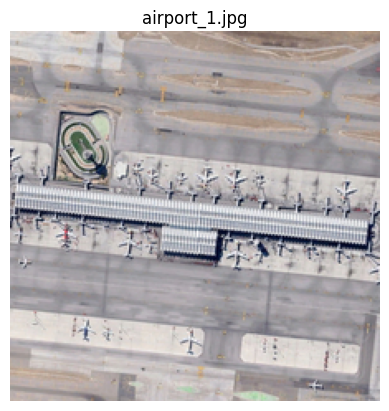

- many planes are parked next to a long building in an airport .
- many planes are parked next to a long building in an airport .
- many planes are parked next to a long building in an airport .
- many planes are parked next to a long building in an airport .
- many planes are parked next to a long building in an airport .


In [46]:
from PIL import Image
import matplotlib.pyplot as plt

example = data_a[0]
img = Image.open(f"data/RSICD_images/{example['filename']}")

plt.imshow(img)
plt.title(example["filename"])
plt.axis("off")
plt.show()

for s in example["sentences"]:
    print(f"- {s['raw']}")

In [47]:
import os
print(os.listdir("data/"))
missing = [img["filename"] for img in data_c if not os.path.exists(f"data/RSICD_images/{img['filename']}")]
print(f"Missing: {len(missing)} out of {len(data_c)}")
print(f"Total images: {len(os.listdir('data/RSICD_images'))}")

['leaderboard_data', 'engjs4tart9t.jpg', 'txtclasses_rsicd', 'RSICD_images', 'RSICD_images(1).zip', 'dataset_rsicd.json']
Missing: 0 out of 1093
Total images: 10921


In [54]:
pairs = []
for img in data_b:
    path = f"data/RSICD_images/{img['filename']}"
    if os.path.exists(path):
        for sent in img["sentences"]:
            pairs.append((path, sent["raw"]))
print(len(pairs))
#print(f"Total training pairs: {len(pairs)}")


5470


In [55]:
from sklearn.model_selection import train_test_split

image_files = list(set([p[0] for p in pairs]))
train_imgs, val_imgs = train_test_split(image_files, test_size=0.2, random_state=42) # 80 procent training, 

train_pairs = [(p, c) for p, c in pairs if p in set(train_imgs)]
val_pairs = [(p, c) for p, c in pairs if p in set(val_imgs)]
print(len(train_pairs))

4375


### lets start with the embeddings

each image has the shape torch.Size([1, 3, 224, 224])
and the text has (training data right now) [1639 ,77] meaning we have [num text, tokens], 77 is the max and whats left after tokenisation will be padded

In [56]:
from rsiddataset import RSIDCDataset
from torch.utils.data import DataLoader

batch_size = 32
train_dataload = RSIDCDataset(pairs =train_pairs, preprocess=preprocess, tokenizer=tokenizer)
val_dataload = RSIDCDataset(pairs =val_pairs, preprocess=preprocess, tokenizer=tokenizer)
image = preprocess(Image.open(f"data/RSICD_images/{example['filename']}")).unsqueeze(0)
train = DataLoader(train_dataload, batch_size=batch_size, shuffle = True) # shuffle makes us shuffle data each epoch 
val =  DataLoader(val_dataload, batch_size=batch_size, shuffle = False) 
print(len(train))


137


### Here we are defining the loss function. 
Taken from the slides from lecture 8  in the course. 

### Training loop 

some nice things to know, i know Dr J.AlmQ doesent like messy notebooks so i remove all my prints from the block and add important stuff here. 

images.shape   # (8, 3, 224, 224)

tokens.shape   # (8, 77)

image = model.encode_image(images)  has shape ([8, 512])

text  = model.encode_text(tokens) # ([8, 512])

calc = image @text.T  # [8, 512] @ [512,8] = [8,8] so a predictino for each batch


Just a notation about the model.logit_sclae. 

That is the temperature, usually its learned ( if we just do  logit_scale = model.logit_scale.exp())

But by making its gradient to false we can use what temperature we want. so atm its fixed. maybe want to try something during eval and the report ? 

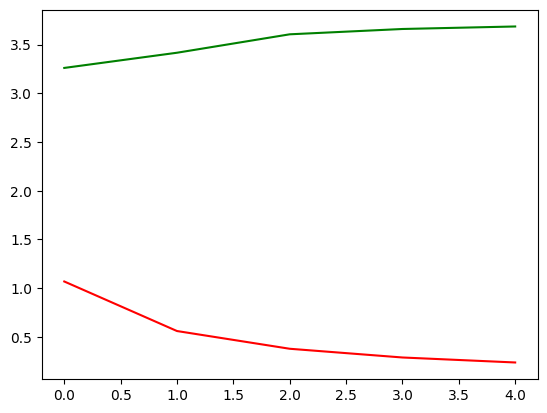

In [64]:
import numpy as np
loss_func = torch.nn.functional.cross_entropy
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
loss_list = []
val_loss = []
epochs = 5 
#temperature = 0.07 # t = 0.07 , this is the default of clip. 
#model.logit_scale.requires_grad = False
#model.logit_scale.data = torch.tensor(np.log(1/temperature)) # 
model.visual.requires_grad_(False) # train only text emb
for i in range(epochs):
    epoch_loss = 0
    for images, tokens in train:
        optimizer.zero_grad()

        labels = torch.arange(images.shape[0]).to(device)
        images = images.to(device)
        tokens = tokens.to(device)
        image = model.encode_image(images) # ([8, 512])
        text  = model.encode_text(tokens) # ([8, 512])
        logit_scale = model.logit_scale.exp() # use for scaling
        image = image / image.norm(dim=-1, keepdim=True) # normalize
        text = text / text.norm(dim=-1, keepdim=True)   
        pred = logit_scale * image @ text.T # [8, 512] @ [512,8] = [8,8] so a predictino for each batch
        loss_image = loss_func(pred,labels)
        loss_text = loss_func(pred.T,labels)
        loss = (loss_image + loss_text)/2
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train)
    loss_list.append(avg_loss)

    model.eval()
    with torch.no_grad():
        val_loop_loss = 0
        for images_v, tokens_v in val:
            labels = torch.arange(images_v.shape[0]).to(device)
            images_v = images_v.to(device)
            tokens_v = tokens_v.to(device)
            image = model.encode_image(images_v) # ([8, 512])
            text  = model.encode_text(tokens_v) # ([8, 512])
            logit_scale = model.logit_scale.exp() # use for scaling
            image = image / image.norm(dim=-1, keepdim=True) # normalize
            text = text / text.norm(dim=-1, keepdim=True)   
            pred = logit_scale * image @ text.T # [8, 512] @ [512,8] = [8,8] so a predictino for each batch
            loss_image = loss_func(pred,labels)
            loss_text = loss_func(pred.T,labels)
            loss = (loss_image + loss_text)/2
            val_loop_loss += loss.item()
        val_loop_loss = val_loop_loss / len(val)
        val_loss.append(val_loop_loss)
        model.train()


    

plt.plot(loss_list, color = 'red',label='train')
plt.plot(val_loss, color = 'green',label='validation')
plt.show()

### Test block. 

Start with the one shot classifier

In [60]:
print(val_loss)
import os
rootdir ='/home/davhe786/fine-tuning-clip-model/data/txtclasses_rsicd'
def get_categories():
    """
        gets the differenet categories of the images
    """
    classifiers = []
    image_class = {}

    for subdir, dirs, files in os.walk(rootdir):
        for file in files:
            path = rootdir + '/' + file
            with open(path) as topo_file:
                for line in topo_file:
                    class_ = file.removesuffix('.txt')
                    line = line.strip('\n').removesuffix('.jpg')
                    image_class.setdefault(class_,[])
                    image_class[class_].append(line)

            class_ = file.removesuffix('.txt') 
            if not class_ in classifiers:
                classifiers.append(file.removesuffix('.txt'))
    return classifiers,image_class

def get_prompt(prompt:str , classifiers: list):
    """
    get the prompt for the classifiers you have. 
    """
    prompts = []
    
    for classifier in classifiers:
        full_text = prompt + classifier
        prompts.append(full_text)
    return prompts

classes,t = get_categories()
prompt = "A satellite image of "
k = get_prompt(prompt, classes)
print(len(k))

[3.075239658355713, 3.149119104657854, 3.3220633711133685, 3.508295358930315, 3.461381278719221]
31


### lets do the actual testing 

In [66]:

classes, image_class = get_categories()
inverse_dict = {}
for class_name, filenames in image_class.items():
    for filename in filenames:
        inverse_dict[filename] = class_name
prompt = "A satellite image of "
prompts = get_prompt(prompt, classes)
text_embedd = tokenizer(prompts).to(device)
test ='/home/davhe786/fine-tuning-clip-model/data/RSICD_images/'
text_emb = model.encode_text(text_embedd)

correct = 0
total = 0
#tokens = self.tokens[idx]
model.eval()
with torch.no_grad():
    for i in data_c:
        path = test + i['filename']
        image =  preprocess(Image.open(path)).to(device)
        image = image.unsqueeze(0)
        final_image = model.encode_image(image)
        image = final_image / final_image.norm(dim=-1, keepdim=True) # normalize
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True) 
        similarity = final_image @ text_emb.T
        predict =torch.argmax(similarity, dim = -1)
        predicted_class = classes[predict.item()]
        true_class = inverse_dict[i['filename'].removesuffix('.jpg')]
        if predicted_class == true_class:
            correct += 1
        total += 1
print(f"Accuracy: {correct}/{total} = {correct/total:.4f}")

Accuracy: 743/1093 = 0.6798
